In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

textes = [
    "Le Machine Learning est une branche de l'Intelligence Artificielle !",
    "Python est le langage #1 pour la Data Science et le ML.",
    "Les réseaux de neurones apprennent à partir de grandes quantités de données.",
    "Le Deep Learning a révolutionné la vision par ordinateur et le NLP."
]

def preprocess(text):
    # 1. Minuscules
    text = text.lower()
    # 2. Supprimer la ponctuation et caractères spéciaux
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿæœ\s]", "", text)
    # 3. Supprimer les espaces multiples
    text = re.sub(r"\s+", " ", text).strip()
    # 4. Tokenisation
    tokens = text.split()
    return tokens

print("=== PREPROCESSING ===")
for i, texte in enumerate(textes):
    tokens = preprocess(texte)
    print(f"\nTexte {i+1} : {texte}")
    print(f"Tokens : {tokens}")

# Vocabulaire
tous_tokens = []
for texte in textes:
    tous_tokens.extend(preprocess(texte))

vocab = Counter(tous_tokens)
print(f"\n=== VOCABULAIRE ===")
print(f"Taille : {len(vocab)}")
print(f"\nMots les plus fréquents :")
for mot, count in vocab.most_common(10):
    print(f"  '{mot}' : {count} fois")

=== PREPROCESSING ===

Texte 1 : Le Machine Learning est une branche de l'Intelligence Artificielle !
Tokens : ['le', 'machine', 'learning', 'est', 'une', 'branche', 'de', 'lintelligence', 'artificielle']

Texte 2 : Python est le langage #1 pour la Data Science et le ML.
Tokens : ['python', 'est', 'le', 'langage', 'pour', 'la', 'data', 'science', 'et', 'le', 'ml']

Texte 3 : Les réseaux de neurones apprennent à partir de grandes quantités de données.
Tokens : ['les', 'réseaux', 'de', 'neurones', 'apprennent', 'à', 'partir', 'de', 'grandes', 'quantités', 'de', 'données']

Texte 4 : Le Deep Learning a révolutionné la vision par ordinateur et le NLP.
Tokens : ['le', 'deep', 'learning', 'a', 'révolutionné', 'la', 'vision', 'par', 'ordinateur', 'et', 'le', 'nlp']

=== VOCABULAIRE ===
Taille : 33

Mots les plus fréquents :
  'le' : 5 fois
  'de' : 4 fois
  'learning' : 2 fois
  'est' : 2 fois
  'la' : 2 fois
  'et' : 2 fois
  'machine' : 1 fois
  'une' : 1 fois
  'branche' : 1 fois
  'lintel

=== MATRICE TF-IDF ===
      de   deep    est  langage     le  learning  machine  meilleur  naturel  neurones    nlp   pour  python  réseaux   sont
0  0.000  0.000  0.580    0.000  0.405     0.405    0.580     0.000    0.000     0.000  0.000  0.000   0.000    0.000  0.000
1  0.448  0.448  0.000    0.000  0.313     0.313    0.000     0.000    0.000     0.448  0.000  0.000   0.000    0.448  0.000
2  0.000  0.000  0.315    0.315  0.441     0.220    0.315     0.391    0.000     0.000  0.000  0.391   0.391    0.000  0.000
3  0.470  0.000  0.000    0.000  0.000     0.000    0.000     0.000    0.000     0.470  0.000  0.000   0.000    0.470  0.582
4  0.000  0.317  0.000    0.317  0.664     0.221    0.000     0.000    0.393     0.000  0.393  0.000   0.000    0.000  0.000

Shape : (5, 15)
→ 5 documents × 15 features (mots)


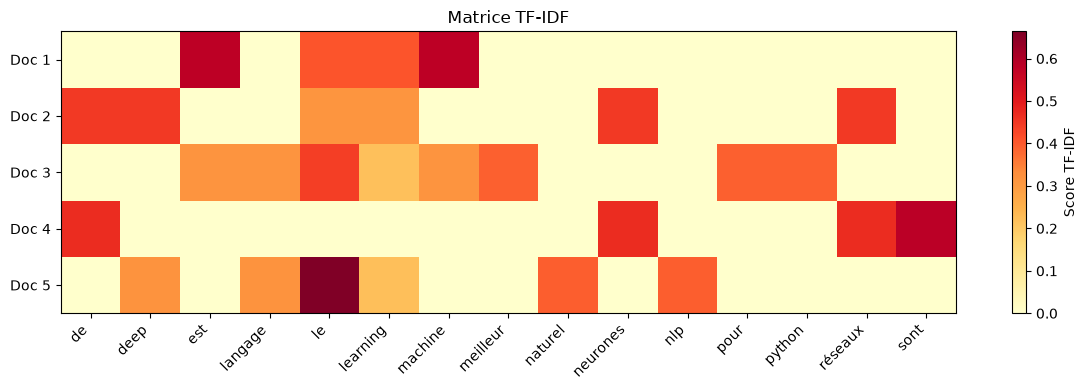


=== SIMILARITÉ COSINUS ENTRE DOCUMENTS ===
       Doc1   Doc2   Doc3   Doc4   Doc5
Doc1  1.000  0.253  0.633  0.000  0.359
Doc2  0.253  1.000  0.207  0.631  0.419
Doc3  0.633  0.207  1.000  0.000  0.441
Doc4  0.000  0.631  0.000  1.000  0.000
Doc5  0.359  0.419  0.441  0.000  1.000


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Corpus de documents
corpus = [
    "le machine learning est fantastique",
    "le deep learning utilise des réseaux de neurones",
    "python est le meilleur langage pour le machine learning",
    "les réseaux de neurones sont inspirés du cerveau humain",
    "le nlp traite le langage naturel avec le deep learning"
]

# TF-IDF
# TF  = fréquence du mot dans le document
# IDF = log(N / nombre de docs contenant le mot)
# TF-IDF = TF × IDF → pénalise les mots trop communs

tfidf = TfidfVectorizer(max_features=15)
X_tfidf = tfidf.fit_transform(corpus)

# Afficher la matrice
df_tfidf = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

print("=== MATRICE TF-IDF ===")
print(df_tfidf.round(3).to_string())

print(f"\nShape : {X_tfidf.shape}")
print("→ 5 documents × 15 features (mots)")

# Visualisation
plt.figure(figsize=(12, 4))
plt.imshow(X_tfidf.toarray(), cmap="YlOrRd", aspect="auto")
plt.colorbar(label="Score TF-IDF")
plt.xticks(range(len(tfidf.get_feature_names_out())),
           tfidf.get_feature_names_out(), rotation=45, ha="right")
plt.yticks(range(5), [f"Doc {i+1}" for i in range(5)])
plt.title("Matrice TF-IDF")
plt.tight_layout()
plt.show()

# Similarité entre documents
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(X_tfidf)
print("\n=== SIMILARITÉ COSINUS ENTRE DOCUMENTS ===")
df_sim = pd.DataFrame(sim.round(3),
                      index=[f"Doc{i+1}" for i in range(5)],
                      columns=[f"Doc{i+1}" for i in range(5)])
print(df_sim)

In [6]:
from transformers import pipeline

print("=== ANALYSE DE SENTIMENTS ===")
sentiment = pipeline("sentiment-analysis")

phrases = [
    "I love this product, it's amazing!",
    "This is terrible, worst experience ever.",
    "It's okay, nothing special.",
    "Absolutely fantastic, highly recommended!"
]

for phrase in phrases:
    result = sentiment(phrase)[0]
    print(f"\nTexte : {phrase}")
    print(f"Sentiment : {result['label']} ({result['score']:.4f})")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


=== ANALYSE DE SENTIMENTS ===


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]


Texte : I love this product, it's amazing!
Sentiment : POSITIVE (0.9999)

Texte : This is terrible, worst experience ever.
Sentiment : NEGATIVE (0.9998)

Texte : It's okay, nothing special.
Sentiment : NEGATIVE (0.8190)

Texte : Absolutely fantastic, highly recommended!
Sentiment : POSITIVE (0.9999)


In [9]:
from transformers import pipeline

# QUESTION ANSWERING
qa = pipeline(
    "text-generation",
    model="distilgpt2"
)

# Alternative simple sans téléchargement supplémentaire
# On utilise le modèle déjà téléchargé pour faire du fill-mask
fill = pipeline("fill-mask", model="distilbert-base-uncased")

exemples = [
    "The capital of Madagascar is [MASK].",
    "Python is the best language for [MASK] learning.",
    "Deep learning uses neural [MASK] to learn patterns."
]

print("=== FILL MASK (complétion de texte) ===\n")
for exemple in exemples:
    results = fill(exemple)
    print(f"Texte   : {exemple}")
    print(f"Meilleure prédiction : '{results[0]['token_str']}' ({results[0]['score']:.4f})")
    print(f"Top 3 : {[r['token_str'] for r in results[:3]]}")
    print()

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

=== FILL MASK (complétion de texte) ===

Texte   : The capital of Madagascar is [MASK].
Meilleure prédiction : 'madagascar' (0.4004)
Top 3 : ['madagascar', 'constantine', 'malaga']

Texte   : Python is the best language for [MASK] learning.
Meilleure prédiction : 'machine' (0.3845)
Top 3 : ['machine', 'python', 'computer']

Texte   : Deep learning uses neural [MASK] to learn patterns.
Meilleure prédiction : 'networks' (0.5681)
Top 3 : ['networks', 'algorithms', 'circuits']



=== SIMILARITÉS COSINUS ===
  sim('roi', 'reine') = 0.6933
  sim('roi', 'homme') = 0.4559
  sim('chien', 'chat') = 0.3830
  sim('chien', 'avion') = 0.2769
  sim('python', 'java') = 0.2126
  sim('paris', 'france') = 0.7374

=== ANALOGIE : roi - homme + femme = ? ===
Top 3 : [('reine', np.float64(0.7287165321132876)), ('voiture', np.float64(0.566282201422695)), ('paris', np.float64(0.4783305685676827))]


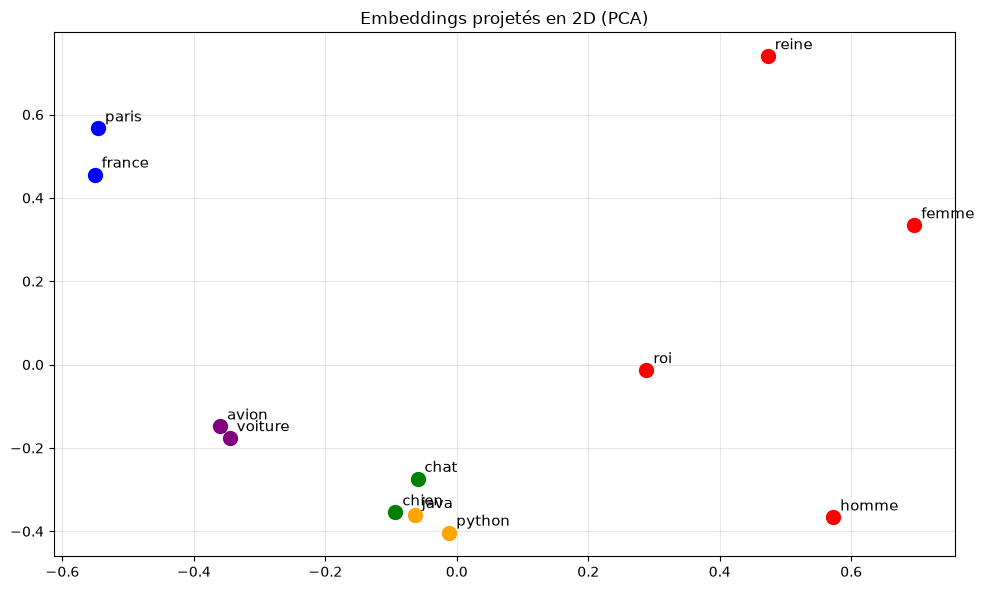

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# WORD EMBEDDINGS
# Représenter les mots comme des vecteurs denses
# Mots sémantiquement proches = vecteurs proches

# Simuler des embeddings (en vrai on utilise Word2Vec ou GloVe)
np.random.seed(42)

# Mots et leurs embeddings simulés (dimension 50)
mots = ["roi", "reine", "homme", "femme", "paris", "france", 
        "chien", "chat", "voiture", "avion", "python", "java"]

# Créer des embeddings avec des relations sémantiques
embeddings = {
    "roi":     np.array([0.9, 0.1, 0.8, 0.1] + list(np.random.randn(46)*0.1)),
    "reine":   np.array([0.9, 0.9, 0.8, 0.1] + list(np.random.randn(46)*0.1)),
    "homme":   np.array([0.1, 0.1, 0.8, 0.1] + list(np.random.randn(46)*0.1)),
    "femme":   np.array([0.1, 0.9, 0.8, 0.1] + list(np.random.randn(46)*0.1)),
    "paris":   np.array([0.5, 0.5, 0.1, 0.9] + list(np.random.randn(46)*0.1)),
    "france":  np.array([0.5, 0.5, 0.1, 0.8] + list(np.random.randn(46)*0.1)),
    "chien":   np.array([0.2, 0.2, 0.1, 0.1] + list(np.random.randn(46)*0.1)),
    "chat":    np.array([0.2, 0.3, 0.1, 0.1] + list(np.random.randn(46)*0.1)),
    "voiture": np.array([0.6, 0.1, 0.1, 0.2] + list(np.random.randn(46)*0.1)),
    "avion":   np.array([0.7, 0.1, 0.1, 0.3] + list(np.random.randn(46)*0.1)),
    "python":  np.array([0.3, 0.1, 0.2, 0.1] + list(np.random.randn(46)*0.1)),
    "java":    np.array([0.3, 0.1, 0.2, 0.2] + list(np.random.randn(46)*0.1)),
}

# Similarité cosinus
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print("=== SIMILARITÉS COSINUS ===")
paires = [
    ("roi", "reine"),
    ("roi", "homme"),
    ("chien", "chat"),
    ("chien", "avion"),
    ("python", "java"),
    ("paris", "france"),
]

for m1, m2 in paires:
    sim = cosine_similarity(embeddings[m1], embeddings[m2])
    print(f"  sim('{m1}', '{m2}') = {sim:.4f}")

# Analogie : roi - homme + femme ≈ reine
print("\n=== ANALOGIE : roi - homme + femme = ? ===")
analogie = embeddings["roi"] - embeddings["homme"] + embeddings["femme"]

similarities = {}
for mot, emb in embeddings.items():
    if mot not in ["roi", "homme", "femme"]:
        similarities[mot] = cosine_similarity(analogie, emb)

top3 = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:3]
print(f"Top 3 : {top3}")

# Visualisation avec PCA
vecteurs = np.array(list(embeddings.values()))
pca = PCA(n_components=2)
vecteurs_2d = pca.fit_transform(vecteurs)

plt.figure(figsize=(10, 6))
couleurs = ["red"]*4 + ["blue"]*2 + ["green"]*2 + ["purple"]*2 + ["orange"]*2
for i, (mot, coords) in enumerate(zip(embeddings.keys(), vecteurs_2d)):
    plt.scatter(coords[0], coords[1], color=couleurs[i], s=100, zorder=5)
    plt.annotate(mot, coords, textcoords="offset points", 
                xytext=(5, 5), fontsize=11)

plt.title("Embeddings projetés en 2D (PCA)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
from transformers import pipeline

# Utiliser un modèle NER plus léger
ner = pipeline(
    "token-classification",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"
)

textes = [
    "Apple was founded by Steve Jobs in California in 1976.",
    "Elon Musk is the CEO of Tesla and SpaceX.",
    "The Eiffel Tower in Paris was built in 1889."
]

print("=== NAMED ENTITY RECOGNITION ===\n")
for texte in textes:
    print(f"Texte : {texte}")
    entities = ner(texte)
    for ent in entities:
        print(f"  [{ent['entity_group']:4s}] '{ent['word']}' ({ent['score']:.3f})")
    print()

print("=== TYPES D'ENTITÉS ===")
print("PER  → Personne (Steve Jobs, Elon Musk)")
print("ORG  → Organisation (Apple, Tesla, SpaceX)")
print("LOC  → Lieu (California, Paris)")
print("MISC → Divers")

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

=== NAMED ENTITY RECOGNITION ===

Texte : Apple was founded by Steve Jobs in California in 1976.
  [ORG ] 'Apple' (0.998)
  [PER ] 'Steve Jobs' (0.996)
  [LOC ] 'California' (1.000)

Texte : Elon Musk is the CEO of Tesla and SpaceX.
  [PER ] 'El' (0.993)
  [PER ] '##on Musk' (0.935)
  [ORG ] 'Tesla' (0.998)
  [ORG ] 'SpaceX' (0.999)

Texte : The Eiffel Tower in Paris was built in 1889.
  [LOC ] 'E' (0.995)
  [LOC ] '##iff' (0.533)
  [LOC ] '##el Tower' (0.937)
  [LOC ] 'Paris' (1.000)

=== TYPES D'ENTITÉS ===
PER  → Personne (Steve Jobs, Elon Musk)
ORG  → Organisation (Apple, Tesla, SpaceX)
LOC  → Lieu (California, Paris)
MISC → Divers


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset
import torch
import numpy as np

data = {
    "text": [
        "This product is amazing and works perfectly!",
        "Terrible quality, broke after one day.",
        "Great value for money, highly recommend.",
        "Waste of money, very disappointed.",
        "Excellent service and fast delivery!",
        "Poor quality and bad customer service.",
        "Best purchase I've made this year!",
        "Complete garbage, do not buy.",
        "Very satisfied with this product.",
        "Awful experience, never buying again.",
        "Outstanding quality and great price!",
        "Broken on arrival, very upset.",
        "Love it! Works exactly as described.",
        "Total disappointment, not worth it.",
        "Perfect product, exceeded expectations!",
        "Horrible, worst product ever made."
    ],
    "label": [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}

dataset = Dataset.from_dict(data)
dataset = dataset.train_test_split(test_size=0.2, seed=42)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True,
                    padding="max_length", max_length=64)

tokenized = dataset.map(tokenize, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": np.mean(predictions == labels)}

training_args = TrainingArguments(
    output_dir="./fine_tuned_model",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="no",        # ← pas de sauvegarde
    logging_steps=5,
    load_best_model_at_end=False,  # ← désactivé
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    compute_metrics=compute_metrics,
)

print("=== FINE-TUNING ===")
trainer.train()

results = trainer.evaluate()
print(f"\n✅ Accuracy : {results['eval_accuracy']:.4f}")

# Test
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)
    pred = torch.argmax(probs).item()
    return "POSITIF" if pred == 1 else "NÉGATIF", probs[0][pred].item()

print("\n=== TEST ===")
tests = [
    "This is the best product I ever bought!",
    "Completely useless, total waste of money.",
    "Good quality but a bit expensive."
]
for text in tests:
    sentiment, conf = predict(text)
    print(f"'{text}' → {sentiment} ({conf:.4f})")

Map:   0%|          | 0/12 [00:00<?, ? examples/s]

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== FINE-TUNING ===


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.669720,0.750000
2,0.685471,0.643519,0.750000
3,0.685471,0.626046,0.750000


Training Loss,Validation Loss,Epoch,Accuracy
0.685471,0.626046,3,0.750000



✅ Accuracy : 0.7500

=== TEST ===


RuntimeError: Placeholder storage has not been allocated on MPS device!

In [3]:
model.to("cpu")

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", 
                      truncation=True, max_length=64)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)
    pred = torch.argmax(probs).item()
    return "POSITIF" if pred == 1 else "NÉGATIF", probs[0][pred].item()

tests = [
    "This is the best product I ever bought!",
    "Completely useless, total waste of money.",
    "Good quality but a bit expensive."
]

print("=== TEST DU MODÈLE FINE-TUNÉ ===")
for text in tests:
    sentiment, conf = predict(text)
    print(f"'{text}'")
    print(f"  → {sentiment} ({conf:.4f})")

=== TEST DU MODÈLE FINE-TUNÉ ===
'This is the best product I ever bought!'
  → POSITIF (0.5910)
'Completely useless, total waste of money.'
  → POSITIF (0.5174)
'Good quality but a bit expensive.'
  → POSITIF (0.5297)


In [3]:
from transformers import pipeline

# SUMMARIZATION avec text-generation
summarizer = pipeline("text-generation", model="distilgpt2")

texte = """Artificial intelligence is intelligence demonstrated by machines. 
AI applications include web search engines, recommendation systems, 
self-driving cars, and generative tools. Machine learning is a subset 
of AI that focuses on building systems that learn from data."""

print("=== RÉSUMÉ AUTOMATIQUE ===\n")
print(f"Texte original ({len(texte.split())} mots) :")
print(texte)

prompt = f"Summarize this text in one sentence: {texte}\nSummary:"
result = summarizer(prompt, max_new_tokens=50, do_sample=False)
summary = result[0]["generated_text"].split("Summary:")[-1].strip()

print(f"\nRésumé généré :")
print(summary)
print(f"\nCompression : {len(summary.split())/len(texte.split()):.1%}")

print("\n✅ Summarization complète !")
print("""
En production on utilise :
  - BART, T5, Pegasus → modèles spécialisés pour le résumé
  - API Claude/GPT-4  → meilleure qualité, plus simple
  - Hugging Face Hub  → des centaines de modèles de résumé disponibles
""")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


=== RÉSUMÉ AUTOMATIQUE ===

Texte original (36 mots) :
Artificial intelligence is intelligence demonstrated by machines. 
AI applications include web search engines, recommendation systems, 
self-driving cars, and generative tools. Machine learning is a subset 
of AI that focuses on building systems that learn from data.


[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



Résumé généré :
Artificial intelligence is a subset of AI that focuses on

Compression : 27.8%

✅ Summarization complète !

En production on utilise :
  - BART, T5, Pegasus → modèles spécialisés pour le résumé
  - API Claude/GPT-4  → meilleure qualité, plus simple
  - Hugging Face Hub  → des centaines de modèles de résumé disponibles

